# Mondrian trees & forests in `online-cp`

The **Mondrian process** recursively partitions feature space into axis-aligned
boxes. Because that partition depends only on the *bag* of feature values (never
their order), a tree grown from the augmented bag $\{\text{train} \cup (x, y)\}$
gives an **exactly valid** conformal predictor, and its leaves form a valid Venn
taxonomy (ALRW2 §2.2.9, Thm 6.4).

This notebook demos the whole family:

- `MondrianTree` — the standalone partition object,
- `ConformalMondrianTree/Forest{Classifier,Regressor}` — conformal predictors,
- `MondrianVennPredictor` — calibrated probabilities,
- the shared inspection tools (`summary`, `to_dataframe`, `debug_one`, `draw`, `draw_partition`).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

from online_cp import (
    MondrianTree,
    ConformalMondrianTreeClassifier,
    ConformalMondrianForestClassifier,
    ConformalMondrianTreeRegressor,
    ConformalMondrianForestRegressor,
    MondrianVennPredictor,
    ErrorRate,
    SetSize,
    IntervalWidth,
    WinklerScore,
    BrierScore,
    progressive_val,
    progressive_val_venn,
)

SEED = 0
rng = np.random.default_rng(SEED)

## A 2-D dataset

We use the classic *two moons* problem (standardised), split into an initial
training set and a held-out stream. Two features let us draw the partition
directly.

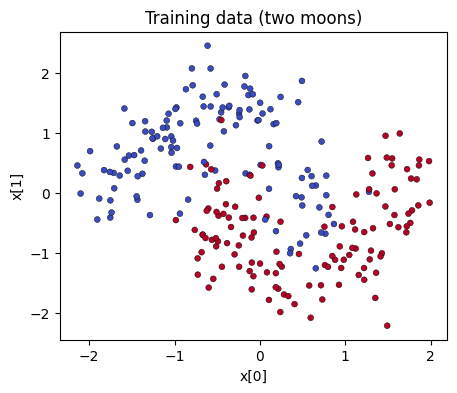

In [2]:
X, y = make_moons(n_samples=400, noise=0.25, random_state=SEED)
X = (X - X.mean(axis=0)) / X.std(axis=0)

n_train = 250
X_tr, y_tr = X[:n_train], y[:n_train]
X_te, y_te = X[n_train:], y[n_train:]

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(X_tr[:, 0], X_tr[:, 1], c=y_tr, cmap="coolwarm",
           s=18, edgecolors="k", linewidths=0.3)
ax.set(title="Training data (two moons)", xlabel="x[0]", ylabel="x[1]")
plt.show()

## The `MondrianTree` core

`MondrianTree.grow(X, rng, lifetime=...)` samples one partition. `lifetime`
controls granularity: larger $\Rightarrow$ more splits $\Rightarrow$ smaller
leaves. The partition is a *bag function* — permutation-invariant in the rows of
`X`.

MondrianTree(lifetime=3.0, n_leaves=50, height=11)
structure: {'n_nodes': 99, 'n_leaves': 50, 'n_branches': 49, 'height': 11}
leaf holds 2 points


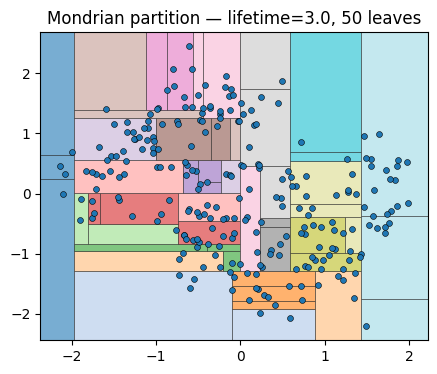

In [3]:
tree = MondrianTree.grow(X_tr, np.random.default_rng(SEED), lifetime=3.0)
print(tree)
print("structure:", tree.struct_stats())

# The leaf containing the first training point:
leaf = tree.find_leaf(X_tr[0])
print("leaf holds", leaf.n_points(), "points")

fig, ax = plt.subplots(figsize=(5, 4))
tree.draw_partition(ax=ax)
ax.set_title(f"Mondrian partition — lifetime=3.0, {len(tree)} leaves")
plt.show()

`draw()` renders the tree itself (here with the built-in matplotlib backend;
install `online-cp[viz]` plus the Graphviz `dot` binary for crisp SVG output).

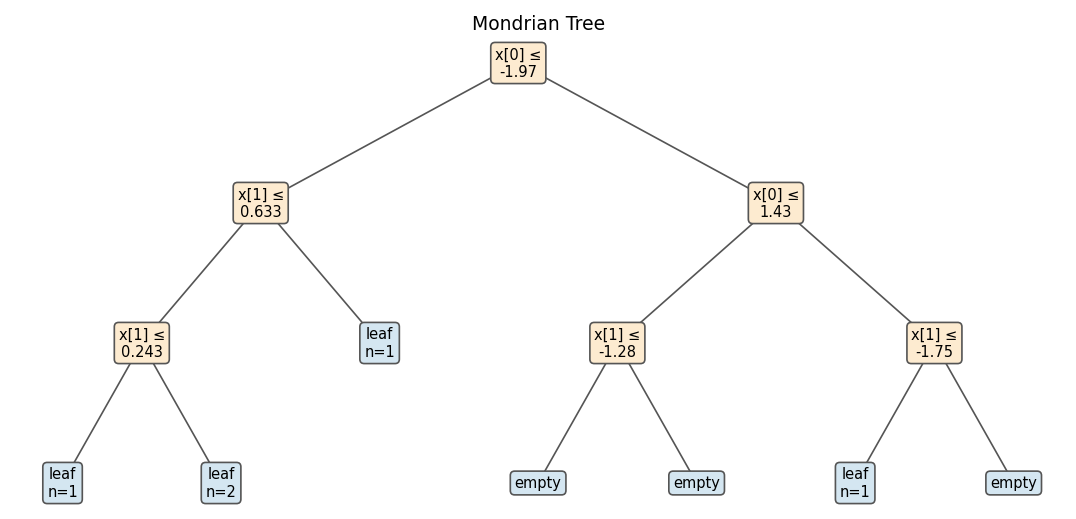

In [16]:
fig, ax = plt.subplots(figsize=(9, 4))
tree.draw(ax=ax, max_depth=3, backend="matplotlib")
plt.show()

## Conformal classification

`ConformalMondrianTreeClassifier` is a full (transductive) conformal predictor:
at each `predict` it rebuilds the tree from the augmented bag and scores
nonconformity in the leaves (Leaf-Local Laplace smoothing). It returns a
**prediction set** guaranteed to cover the truth with probability $\ge 1 -
\varepsilon$.

test point      : [ 0.319 -0.184]
prediction set  : [0]  (size 1 )
p-values        : {0: 0.627, 1: 0.02}


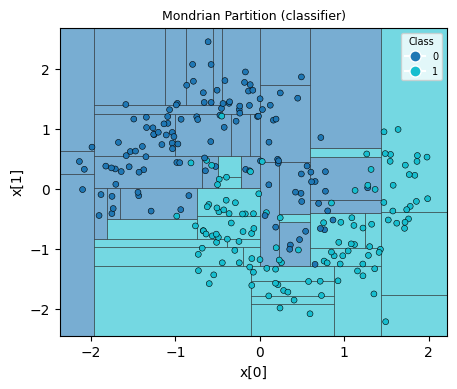

In [5]:
clf = ConformalMondrianTreeClassifier(
    lifetime=3.0, label_space=np.array([0, 1]), rnd_state=SEED
)
clf.learn_initial_training_set(X_tr, y_tr)

Gamma, p_values = clf.predict(X_te[0], epsilon=0.1, return_p_values=True)
print("test point      :", np.round(X_te[0], 3))
print("prediction set  :", Gamma.elements, " (size", len(Gamma), ")")
print("p-values        :", {int(k): round(v, 3) for k, v in p_values.items()})

fig, ax = plt.subplots(figsize=(5, 4))
clf.draw_partition(ax=ax)  # leaves coloured by majority class
plt.show()

### Where is the predictor confident?

Sweeping a grid of test points and recording the **prediction-set size** shows
the conformal geometry: singletons (size 1) where one class dominates, the full
set $\{0, 1\}$ (size 2) in the ambiguous band between the moons, and the
occasional empty set (size 0) far from any data.

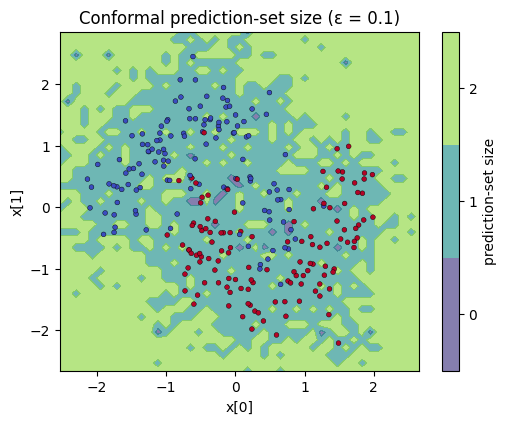

In [6]:
grid_clf = ConformalMondrianTreeClassifier(
    lifetime=3.0, label_space=np.array([0, 1]), rnd_state=SEED
)
grid_clf.learn_initial_training_set(X_tr, y_tr)

gx = np.linspace(X[:, 0].min() - 0.4, X[:, 0].max() + 0.4, 45)
gy = np.linspace(X[:, 1].min() - 0.4, X[:, 1].max() + 0.4, 45)
GX, GY = np.meshgrid(gx, gy)
sizes = np.array([
    len(grid_clf.predict(np.array([a, b]), epsilon=0.1))
    for a, b in zip(GX.ravel(), GY.ravel())
]).reshape(GX.shape)

fig, ax = plt.subplots(figsize=(5.8, 4.4))
cf = ax.contourf(GX, GY, sizes, levels=[-0.5, 0.5, 1.5, 2.5],
                 cmap="viridis", alpha=0.65)
ax.scatter(X_tr[:, 0], X_tr[:, 1], c=y_tr, cmap="coolwarm",
           s=12, edgecolors="k", linewidths=0.3)
cbar = fig.colorbar(cf, ax=ax, ticks=[0, 1, 2])
cbar.set_label("prediction-set size")
ax.set(title="Conformal prediction-set size (ε = 0.1)", xlabel="x[0]", ylabel="x[1]")
plt.show()

### Online validity

Progressive (test-then-train) validation over the held-out stream. At
$\varepsilon = 0.1$ the long-run error rate should sit near $0.1$.

In [7]:
clf = ConformalMondrianTreeClassifier(
    lifetime=3.0, label_space=np.array([0, 1]), rnd_state=SEED
)
clf.learn_initial_training_set(X_tr, y_tr)

metric = ErrorRate() + SetSize()
metric = progressive_val(clf, X_te, y_te, epsilon=0.1, metric=metric)
print(metric.get())

{'ErrorRate': 0.08666666666666667, 'SetSize': 1.1066666666666667}


## Forests

`ConformalMondrianForestClassifier` averages leaf posteriors over `n_trees`
independent Mondrian trees, giving smoother nonconformity scores.

forest prediction set: [0]


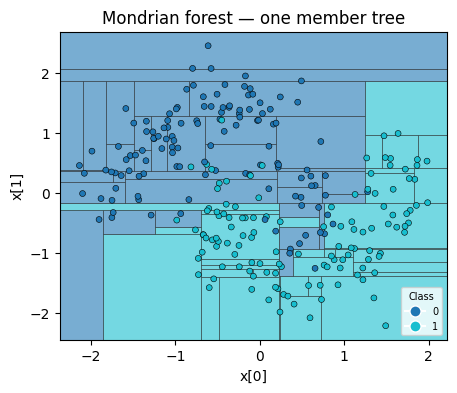

In [8]:
forest = ConformalMondrianForestClassifier(
    n_trees=30, lifetime=3.0, label_space=np.array([0, 1]), rnd_state=SEED, n_jobs=-1
)
forest.learn_initial_training_set(X_tr, y_tr)

Gamma = forest.predict(X_te[0], epsilon=0.1)
print("forest prediction set:", Gamma.elements)

fig, ax = plt.subplots(figsize=(5, 4))
forest.draw_partition(ax=ax)  # the forest's last cached tree
ax.set_title("Mondrian forest — one member tree")
plt.show()

## Conformal regression

For regression the nonconformity measure is the leaf residual
$|y_i - \mu_{\text{leaf}}(x_i)|$. A **single tree** solves the interval *exactly*
with an $O(n)$ knot-point solver — which can legitimately return an *unbounded*
interval for points in sparse edge regions (an honest reflection of conformal
validity). A **forest** aggregates residuals across trees and solves on a bounded
grid, so its intervals are always finite. We build a smooth 2-D target.

interval [-0.075, 0.792]  width=0.867  true y=0.522


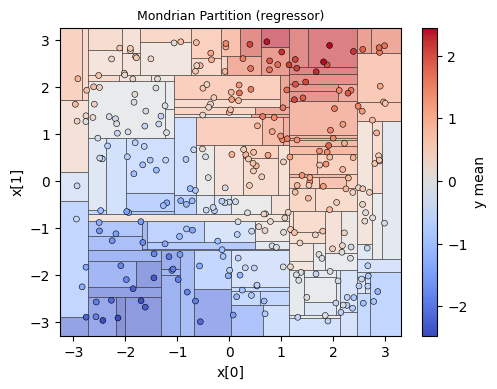

In [9]:
Xr = rng.uniform(-3, 3, size=(400, 2))
yr = np.sin(Xr[:, 0]) + 0.5 * Xr[:, 1] + 0.2 * rng.normal(size=400)
Xr_tr, yr_tr = Xr[:300], yr[:300]
Xr_te, yr_te = Xr[300:], yr[300:]

reg = ConformalMondrianTreeRegressor(lifetime=3.0, rnd_state=SEED)
reg.learn_initial_training_set(Xr_tr, yr_tr)

interval = reg.predict(Xr_te[0], epsilon=0.1)
print(f"interval [{interval.lower:.3f}, {interval.upper:.3f}]  "
      f"width={interval.width():.3f}  true y={yr_te[0]:.3f}")

fig, ax = plt.subplots(figsize=(5.5, 4))
reg.draw_partition(ax=ax)  # leaves coloured by their mean y
plt.show()

### Online validity (forest regressor)

The **forest** regressor's grid solver keeps every interval finite, so we can
track width and Winkler score alongside the error rate over the stream.

In [10]:
reg = ConformalMondrianForestRegressor(
    n_trees=15, lifetime=3.0, rnd_state=SEED, n_jobs=-1
)
reg.learn_initial_training_set(Xr_tr, yr_tr)

m = ErrorRate() + IntervalWidth() + WinklerScore()
m = progressive_val(reg, Xr_te, yr_te, epsilon=0.1, metric=m)
print({k: round(float(v), 3) for k, v in m.get().items()})

{'ErrorRate': 0.08, 'IntervalWidth': 0.868, 'WinklerScore': 1.04}


## Calibrated probabilities: Mondrian Venn

`MondrianVennPredictor` uses the Mondrian leaf as the Venn *taxonomy* category.
The output is a multiprobability prediction; for binary problems it exposes
`p0`/`p1` (the probability of class 1 under each hypothesis) and an aggregate
`point` probability. Validity follows from the bag-function property
(ALRW2 Thm 6.4). Setting `min_samples_leaf=2` avoids singleton leaves that would
force degenerate $0/1$ probabilities.

In [11]:
venn = MondrianVennPredictor(lifetime=2.0, min_samples_leaf=2, rnd_state=SEED)
venn.learn_initial_training_set(X_tr, y_tr)

pred = venn.predict(X_te[0])
print(pred)
print("aggregate point probabilities:", np.round(pred.point, 3))

# Online Brier score over the stream (lower is better):
venn = MondrianVennPredictor(lifetime=2.0, min_samples_leaf=2, rnd_state=SEED)
venn.learn_initial_training_set(X_tr, y_tr)
vm = progressive_val_venn(venn, X_te, y_te, metric=BrierScore())
print("Brier score:", round(vm.get(), 4))

(p0=0.7297, p1=0.7365)
aggregate point probabilities: [0.267 0.733]
Brier score: 0.2078


## Inspecting a fitted model

Every tree/forest predictor shares the same inspection tools, all reading the
tree cached during the most recent `predict`.

In [12]:
clf = ConformalMondrianTreeClassifier(
    lifetime=3.0, label_space=np.array([0, 1]), rnd_state=SEED
)
clf.learn_initial_training_set(X_tr, y_tr)
clf.predict(X_te[0], epsilon=0.1)  # caches a tree

print("summary:")
for k, v in clf.summary.items():
    print(f"  {k}: {v}")

print("\ndecision path for the test point:")
print(clf.debug_one(X_te[0]))

summary:
  n_points: 250
  n_features: 2
  n_classes: 2
  label_space: [np.int64(0), np.int64(1)]
  lifetime: 3.0
  epsilon: 0.1
  n_nodes: 99
  n_leaves: 50
  n_branches: 49
  height: 11
  total_observed_weight: 250

decision path for the test point:
  x[0] <= -1.969258  [FALSE → right]
    x[0] <= 1.432404  [TRUE → left]
      x[1] <= -1.279756  [FALSE → right]
        x[0] <= -0.000176  [FALSE → right]
          x[0] <= 0.590332  [TRUE → left]
            x[1] <= 1.734905  [TRUE → left]
              x[1] <= 0.450295  [TRUE → left]
                x[0] <= 0.227824  [FALSE → right]
                  x[1] <= -0.557089  [FALSE → right]
                    x[1] <= -0.410799  [FALSE → right]
                      LEAF: n_points=6


In [13]:
clf.to_dataframe().head(8)

,node_id,parent_id,is_leaf,depth,split_dim,split_loc,split_time,parent_time,bbox_lower,bbox_upper,n_points,counts
0,0,NaN,False,0,0,-1.969258,0.077466,0.000000,"[-2.138307617189273, -2.205636546113532]","[1.9875100898834464, 2.445687229212313]",0,NaN
1,1,0.0,False,1,1,0.632988,0.080125,0.077466,"[-2.138307617189273, -0.010066991371036099]","[-1.9894432579964254, 0.6944531522368819]",0,NaN
2,2,1.0,False,2,1,0.243348,1.364504,0.080125,"[-2.138307617189273, -0.010066991371036099]","[-2.0800224981416657, 0.4560905121527453]",0,NaN
3,3,2.0,True,3,-1,NaN,NaN,1.364504,"[-2.1008254175671564, -0.010066991371036099]","[-2.1008254175671564, -0.010066991371036099]",1,"{0: 1, 1: 0}"
4,4,2.0,True,3,-1,NaN,NaN,1.364504,"[-2.138307617189273, 0.32634442416251885]","[-2.0800224981416657, 0.4560905121527453]",2,"{0: 2, 1: 0}"
5,5,1.0,True,2,-1,NaN,NaN,0.080125,"[-1.9894432579964254, 0.6944531522368819]","[-1.9894432579964254, 0.6944531522368819]",1,"{0: 1, 1: 0}"
6,6,0.0,False,1,0,1.432404,0.462105,0.077466,"[-1.9053563592359894, -2.205636546113532]","[1.9875100898834464, 2.445687229212313]",0,NaN
7,7,6.0,False,2,1,-1.279756,0.471337,0.462105,"[-1.9053563592359894, -2.0735924803462504]","[1.4281187050007718, 2.445687229212313]",0,NaN


## Where to next

- **Guide:** *Mondrian Prediction* → adaptive tree & forest predictors.
- **API:** `online_cp.mondrian.MondrianTree`, the `ConformalMondrian*` classes,
  and `MondrianVennPredictor`.
- `lifetime` can auto-tune unsupervised with `lifetime="sqrt_n"` or
  `lifetime="density"` (labels are never used).
